# Visualization

In [6]:
# lib import
import os
from datasets import Dataset, load_dataset  # , get_dataset_config_names,

# setup
# configs = get_dataset_config_names("whatphiliptrains/wikipos")
img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)
source_ds_cache_dir = os.path.join(os.getcwd(), "data", "wikipos")
subset_size = None


def get_subset(ds: Dataset, size: int | None = None, seed: int = 97) -> Dataset:
    ds_shuffled = ds.shuffle(seed=seed)
    if size is None:
        subset = ds_shuffled
    else:
        subset = ds_shuffled.select(range(size))
    return subset


def load(config: str) -> Dataset:
    dataset = load_dataset(
        "whatphiliptrains/wikipos",
        name=config,
        cache_dir=source_ds_cache_dir,
        split="train",
    )
    return dataset

In [7]:
tsne = [
    "all_MiniLM_L6_v2_tsne",
    "all_mpnet_base_v2_tsne",
    "nomic_embed_text_v1_5_tsne",
]
umap = [
    "all_MiniLM_L6_v2_umap",
    "all_mpnet_base_v2_umap",
    "nomic_embed_text_v1_5_umap",
]
umap_pca = [
    "all_MiniLM_L6_v2_umap_pca",
    "all_mpnet_base_v2_umap_pca",
    "nomic_embed_text_v1_5_umap_pca",
]

In [ ]:
ds = load(tsne[0])
# random selection of 10 / 20 entries across all configs

In [ ]:
import matplotlib.pyplot as plt
import datashader as ds
from datashader.mpl_ext import dsshow, alpha_colormap
import os

configs = tsne + umap

for config in configs:
    print(f"Processing config: {config}")
    print("Loading data...")
    dataset = load(config)

    print("Converting subset to DataFrame...")
    df = dataset.to_pandas()

    print("Generating and saving plot...")
    fig, ax = plt.subplots(figsize=(8, 8), facecolor="none")
    ax.set_facecolor("none")

    artist = dsshow(
        df,
        ds.Point("x", "y"),
        ds.count(),
        norm="log",
        cmap=alpha_colormap("#E63E0F", min_alpha=120),
        x_range=(-1.0, 1.0),
        y_range=(-1.0, 1.0),
        ax=ax,
    )

    # Set tick marks and labels
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
    ax.set_yticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])

    filepath = os.path.join(img_dir, f"{config}.png")
    plt.savefig(filepath, format="png", bbox_inches="tight", dpi=300, transparent=True)
    print(f"Saved plot to: {filepath}")

    plt.show()

Loading:  all_MiniLM_L6_v2_umap_pca
Converting subset to DataFrame...
Converting subset to DataFrame...
Generating and saving plot...
Generating and saving plot...
Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/all_MiniLM_L6_v2_umap_pca.png
Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/all_MiniLM_L6_v2_umap_pca.png


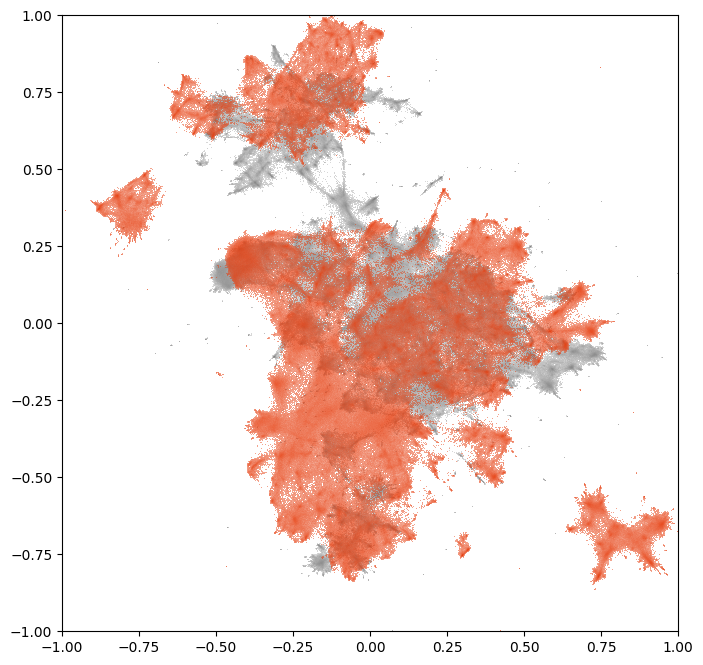

Loading:  all_mpnet_base_v2_umap_pca


Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Converting subset to DataFrame...
Generating and saving plot...
Generating and saving plot...
Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/all_mpnet_base_v2_umap_pca.png
Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/all_mpnet_base_v2_umap_pca.png


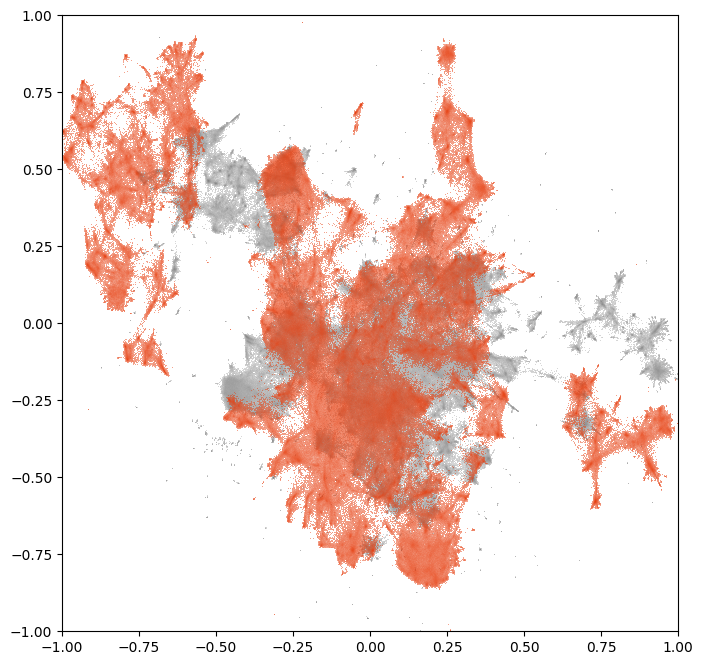

Loading:  nomic_embed_text_v1_5_umap_pca


Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Converting subset to DataFrame...
Generating and saving plot...
Generating and saving plot...
Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/nomic_embed_text_v1_5_umap_pca.png
Saved plot to: /Users/philip/Documents/Repos/ctech/submissions/acme-paper/src/img/nomic_embed_text_v1_5_umap_pca.png


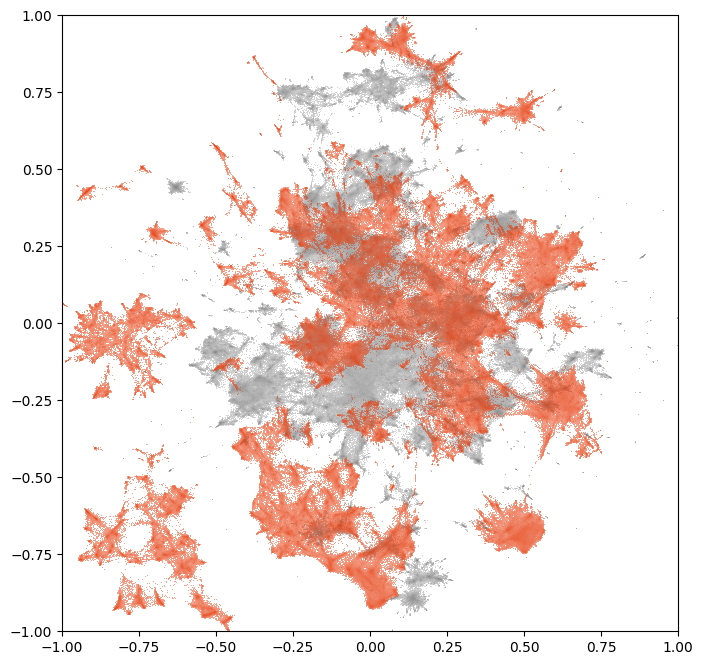

In [8]:
import matplotlib.pyplot as plt
import datashader as ds
from datashader.mpl_ext import dsshow, alpha_colormap
import os

configs = umap_pca

for i, config in enumerate(configs):
    print("Loading: ", config)
    ds_umap_pca = load(config)
    ds_umap = load(umap[i])

    print("Converting subset to DataFrame...")
    df_umap_pca = ds_umap_pca.to_pandas()
    df_umap = ds_umap.to_pandas()

    print("Generating and saving plot...")
    fig, ax = plt.subplots(figsize=(8, 8), facecolor="none")
    ax.set_facecolor("none")

    # First plot the grey UMAP scatterplot
    artist_umap = dsshow(
        df_umap,
        ds.Point("x", "y"),
        ds.count(),
        norm="log",
        cmap=alpha_colormap("#808080", min_alpha=80),  # Grey color
        x_range=(-1.0, 1.0),
        y_range=(-1.0, 1.0),
        ax=ax,
    )

    # Then plot the orange UMAP-PCA scatterplot on top
    artist = dsshow(
        df_umap_pca,
        ds.Point("x", "y"),
        ds.count(),
        norm="log",
        cmap=alpha_colormap("#E63E0F", min_alpha=120),
        x_range=(-1.0, 1.0),
        y_range=(-1.0, 1.0),
        ax=ax,
    )

    # Set tick marks and labels
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
    ax.set_yticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])

    filepath = os.path.join(img_dir, f"{config}.png")
    plt.savefig(filepath, format="png", bbox_inches="tight", dpi=300, transparent=True)
    print(f"Saved plot to: {filepath}")

    plt.show()